# 2D Cross-Section Analysis of Mass Concentration

This notebook interpolates the predicted 3D data onto a 2D vertical cross-section plane between two points. It visualizes the final time step using the faster nearest-neighbor interpolation option.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pickle
from scipy.interpolate import griddata

In [2]:
# Define results directory and load data
# results_dir = os.path.expanduser('~/OneDrive - The University of Sydney (Staff)/Shared/Projects/01_PhD/03_Physics_Informed/05_groundwater/groundwater_main/results/')
# results_dir = os.path.expanduser('~/Projects/groundwater/results/gw_sciml/')
results_dir = '/scratch/yl75/ak4177/results/groundwater/'

# Model results directory
gino_vl_res_dir = os.path.join(results_dir, 'GINO_predictions/var_loss/resolution_1.0/gino_predictions_20260721_072032')
gino_res_dir = os.path.join(results_dir, 'GINO_predictions/standard/resolution_1.0/gino_predictions_20260721_072032')
fno_res_dir = os.path.join(results_dir, 'FNO_predictions/forcing/resolution_1.0/fno_predictions_20260721_130903')

In [3]:
# Load predictions
gino_vl_preds = np.clip(np.load(os.path.join(gino_vl_res_dir, 'val_predictions.npy'))[-1, :, 0], 0, None)
gino_preds = np.clip(np.load(os.path.join(gino_res_dir, 'val_predictions.npy'))[-1, :, 0], 0, None)
fno_preds =  np.clip(np.load(os.path.join(fno_res_dir, 'val_predictions.npy'))[-1, :, 0], 0, None)

# Coords
coords = pickle.load(open(os.path.join(fno_res_dir, 'train_coords.pkl'), 'rb'))[0]

# Load Targets
targets = np.load(os.path.join(fno_res_dir, 'val_targets.npy'))[-1, :, 0]

# Apply inverse coordinate transformation
coord_mean = np.array([357225.66528974305, 6457743.243307921, -9.277822477621577])
coord_std = np.array([569.1699998979727, 566.3579737855055, 15.2656561762675])
unnorm_coords = coords * coord_std + coord_mean

In [4]:
print(f"Data shape for last time step (preds): {gino_vl_preds.shape}")
print(f"Data shape for last time step (preds): {gino_preds.shape}")
print(f"Data shape for last time step (preds): {fno_preds.shape}")
print(f"Data shape for last time step (targets): {targets.shape}")

Data shape for last time step (preds): (61360, 2)
Data shape for last time step (preds): (61360, 2)
Data shape for last time step (preds): (61360, 2)
Data shape for last time step (targets): (61360, 2)


In [5]:
import matplotlib.tri as mtri
from scipy.spatial import KDTree

# Define Points P1 and P2
p1 = np.array([356835.28, 6459067.43])
p2 = np.array([357877.28, 6457548.86])

# Calculate transect vector
dx_L = p2[0] - p1[0]
dy_L = p2[1] - p1[1]
length = np.hypot(dx_L, dy_L)

print("Reading FEFLOW ASCII Mesh to extract exact geometry...")
# file_path = os.path.expanduser('~/OneDrive - The University of Sydney (Staff)/Shared/Data/FEFLOW/simulation_files/ascii_mesh.fem')
file_path = '/scratch/yl75/ak4177/data/feflow_data/ascii_mesh.fem'

# 1. Parse the 2D elements and coordinates from ASCII Mesh
n2d = 2360
elements_2d = []
coor_vals = []
in_node = False
in_coor = False

with open(file_path, 'r', errors='ignore') as f:
    for l in f:
        l = l.strip()
        
        # Parse elements
        if l == 'NODE':
            in_node = True
            continue
        if in_node and (len(l)>0 and l[0].isalpha() and l[0].isupper()):
            in_node = False 
        elif in_node:
            nodes = [int(n) - 1 for n in l.split()]
            if nodes[0] < n2d: 
                elements_2d.append(nodes[:3])
                
        # Parse coordinates
        if l == 'COOR':
            in_coor = True
            continue
        if in_coor and (len(l)>0 and l[0].isalpha() and l[0].isupper()):
            in_coor = False
        elif in_coor:
            parts = l.split(',')
            for p in parts:
                if p.strip(): coor_vals.append(float(p))

x_mesh = np.array(coor_vals[:n2d])
y_mesh = np.array(coor_vals[n2d:2*n2d])

# Calculate precise coordinate shift from normalized predictions dataset bounds
shift_x = unnorm_coords[:, 0].min() - x_mesh.min()
shift_y = unnorm_coords[:, 1].min() - y_mesh.min()
x_utm = x_mesh + shift_x
y_utm = y_mesh + shift_y
xy_2d = np.column_stack((x_utm, y_utm))

print(f"Extracted {len(elements_2d)} 2D basis triangles.")

Reading FEFLOW ASCII Mesh to extract exact geometry...
Extracted 4564 2D basis triangles.


In [6]:
# 2. Map the geometry exactly to the unordered predictions dataset
# The `unnorm_coords` has 61360 points in seemingly random 3D layout. 
# For each 2D footprint node, fetch all 26 Z-levels and sort them from bottom to top.
num_slices = 26
tree_2d = KDTree(unnorm_coords[:, :2])
dists_all, indices_all = tree_2d.query(xy_2d, k=num_slices)

# mapped_indices[i, k] will hold the dataset index of the k-th Z-layer of 2D node i
mapped_indices = np.zeros((n2d, num_slices), dtype=int)

for i in range(n2d):
    # Retrieve indices of the 26 points mapped to footprint node `i`
    vertical_indices = indices_all[i]
    # Sort them by their Z coordinate (ascending, bottom to top)
    z_coords_node = unnorm_coords[vertical_indices, 2]
    sorted_order = np.argsort(z_coords_node)
    mapped_indices[i] = vertical_indices[sorted_order]

print("Successfully mapped vertical topology arrays.")

Successfully mapped vertical topology arrays.


In [7]:
# 3. Compute exact intersections of the 2D plane with all 2D triangles
intersecting_panels = []

for elem in elements_2d:
    pts = xy_2d[elem]
    hits = []
    # Test all 3 triangle edges
    for i, j in [(0,1), (1,2), (2,0)]:
        A, B = pts[i], pts[j]
        dx_E = B[0] - A[0]
        dy_E = B[1] - A[1]
        det = dx_L * dy_E - dy_L * dx_E
        if abs(det) < 1e-10: continue
            
        dx_AP = A[0] - p1[0]
        dy_AP = A[1] - p1[1]
        t_L = (dx_AP * dy_E - dy_AP * dx_E) / det
        t_E = (dx_AP * dy_L - dy_AP * dx_L) / det
        
        if 0 <= t_L <= 1 and -1e-5 <= t_E <= 1+1e-5:
            hits.append((t_L, t_E, elem[i], elem[j]))
            
    if len(hits) >= 2:
        hits.sort(key=lambda x: x[0])
        h1, h2 = hits[0], hits[-1]
        if h2[0] - h1[0] > 1e-5: # Avoid numerical phantom grazes
            intersecting_panels.append({
                's1': h1[0] * length, 'w1': h1[1], 'e1': (h1[2], h1[3]),
                's2': h2[0] * length, 'w2': h2[1], 'e2': (h2[2], h2[3])
            })

print(f"Slice plane cuts through {len(intersecting_panels)} elements.")

Slice plane cuts through 91 elements.


In [8]:
def excrude_3d_domain(mass_conc_targets_last_step, mass_conc_preds_last_step):
    # Select only the first output channel (mass concentration) if multi-channel
    if np.asarray(mass_conc_preds_last_step).ndim > 1:
        mass_conc_preds_last_step = np.asarray(mass_conc_preds_last_step)[:, 0]
    if np.asarray(mass_conc_targets_last_step).ndim > 1:
        mass_conc_targets_last_step = np.asarray(mass_conc_targets_last_step)[:, 0]
    # 4. Extrude the cuts over the 3D domain to build the precise cross-section geometry
    s_coords = []
    z_coords = []
    preds_vals = []
    targets_vals = []
    triangles = []
    
    node_counter = 0
    
    for panel in intersecting_panels:
        s1, w1, e1 = panel['s1'], panel['w1'], panel['e1']
        s2, w2, e2 = panel['s2'], panel['w2'], panel['e2']
        
        # Start at bottom layer and go to top
        for k in range(num_slices):
            idx_n1a, idx_n1b = mapped_indices[e1[0], k], mapped_indices[e1[1], k]
            idx_n2a, idx_n2b = mapped_indices[e2[0], k], mapped_indices[e2[1], k]
            
            # Interpolate spatial Z height exactly on the triangle face edge
            z1 = unnorm_coords[idx_n1a, 2] + w1 * (unnorm_coords[idx_n1b, 2] - unnorm_coords[idx_n1a, 2])
            z2 = unnorm_coords[idx_n2a, 2] + w2 * (unnorm_coords[idx_n2b, 2] - unnorm_coords[idx_n2a, 2])
            
            # Interpolate target and predicted concentration exactly on the element edge
            p1_val = mass_conc_preds_last_step[idx_n1a] + w1 * (mass_conc_preds_last_step[idx_n1b] - mass_conc_preds_last_step[idx_n1a])
            p2_val = mass_conc_preds_last_step[idx_n2a] + w2 * (mass_conc_preds_last_step[idx_n2b] - mass_conc_preds_last_step[idx_n2a])
            
            t1_val = mass_conc_targets_last_step[idx_n1a] + w1 * (mass_conc_targets_last_step[idx_n1b] - mass_conc_targets_last_step[idx_n1a])
            t2_val = mass_conc_targets_last_step[idx_n2a] + w2 * (mass_conc_targets_last_step[idx_n2b] - mass_conc_targets_last_step[idx_n2a])
    
            # Save vertices for this slice height
            s_coords.extend([s1, s2])
            z_coords.extend([z1, z2])
            preds_vals.extend([p1_val, p2_val])
            targets_vals.extend([t1_val, t2_val])
            
            # Build logical quadrilateral faces between layer k-1 and layer k
            if k > 0:
                idx_bot1 = node_counter - 2
                idx_bot2 = node_counter - 1
                idx_top1 = node_counter
                idx_top2 = node_counter + 1
                
                # Quad -> 2 Triangles
                triangles.append([idx_bot1, idx_bot2, idx_top1])
                triangles.append([idx_bot2, idx_top2, idx_top1])
                
            node_counter += 2
    
    s_coords = np.array(s_coords)
    z_coords = np.array(z_coords)
    preds_vals = np.array(preds_vals)
    targets_vals = np.array(targets_vals)
    triangles = np.array(triangles)

    print(f"Generated {len(triangles)} accurate finite element faces in 2D space.")

    return s_coords, z_coords, triangles, preds_vals, targets_vals

In [9]:
s_coords, z_coords, triangles, gino_vl_preds_vals, targets_vals = excrude_3d_domain(targets, gino_vl_preds)
_, _, _, gino_preds_vals, _ = excrude_3d_domain(targets, gino_preds)
_, _, _, fno_preds_vals, _ = excrude_3d_domain(targets, fno_preds)

s_coords.shape, z_coords.shape, triangles.shape, gino_vl_preds_vals.shape

Generated 4550 accurate finite element faces in 2D space.
Generated 4550 accurate finite element faces in 2D space.
Generated 4550 accurate finite element faces in 2D space.


((4732,), (4732,), (4550, 3), (4732,))

In [16]:
import matplotlib.colors as mcolors

def plot_cross_section(targets_vals):

    # Make the figure much wider and shorter to fit the long cross-section proportionally
    fig, ax = plt.subplots(figsize=(8, 6), sharex=True, sharey=True)
    
    # Define exact sequence of FEFLOW color levels
    levels = [-30000, 0, 1000, 5000, 10000, 15000, 20000, 25000, 30000, 34500, 55000]
    
    # Tweak the hex colors to exactly mimic your FEFLOW screenshot legend visually
    feflow_colors = [
        '#5E4FA2', # < 0 (Purple)
        '#3973B5', # 0 - 1000 (Medium Blue)
        '#4CB2D4', # 1000 - 5000 (Cyan/Light Blue)
        '#32C2A3', # 5000 - 10000 (Teal)
        '#45D86A', # 10000 - 15000 (Light Green)
        '#8DEB45', # 15000 - 20000 (Lime Green)
        '#C4FA4B', # 20000 - 25000 (Yellow-Green)
        '#E7FE57', # 25000 - 30000 (Pale Yellow)
        '#FEE44F', # 30000 - 34500 (Golden Yellow)
        '#FB9736', # > 34500 (Orange - Densest fluid at bottom)
    ]
    
    cmap = mcolors.LinearSegmentedColormap.from_list('feflow_continuous', feflow_colors)
    norm = mcolors.Normalize(vmin=0, vmax=35000)
    contour_kwargs = dict(levels=np.linspace(0, 35000, 100), cmap=cmap, norm=norm, extend='both')
    
    # Create the rigid, exact finite element triangulation object
    triangulation = mtri.Triangulation(s_coords, z_coords, triangles)
    cf_target = ax.tricontourf(triangulation, targets_vals, **contour_kwargs)
    ax.set_xlabel(f'Distance along transect from P1 (m)\nP1=({p1[0]:.2f}, {p1[1]:.2f})    P2=({p2[0]:.2f}, {p2[1]:.2f})')
    ax.set_ylabel('Elevation Z (m)')
    ax.set_facecolor('white')
    
    plt.xlim(s_coords.min(), s_coords.max())
    plt.ylim(z_coords.min(), z_coords.max())
    
    # Optimize spacing layout before adding the independent colorbar
    plt.tight_layout()
    
    # Adjust the right margin to make room for a dedicated colorbar axis
    # This strictly prevents the colorbar from expanding and crushing the plots
    fig.subplots_adjust(right=0.88)
    
    # [left, bottom, width, height] of the new colorbar axis
    cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7]) 
    
    # Add a single colorbar for both subplots locked to its own neat axis box
    cbar = fig.colorbar(cf_target, cax=cbar_ax, label='Mass Concentration (mg/l)', extend='both')
    cbar.set_ticks([0, 1000, 5000, 10000, 15000, 20000, 25000, 30000, 34500])
    
    return fig

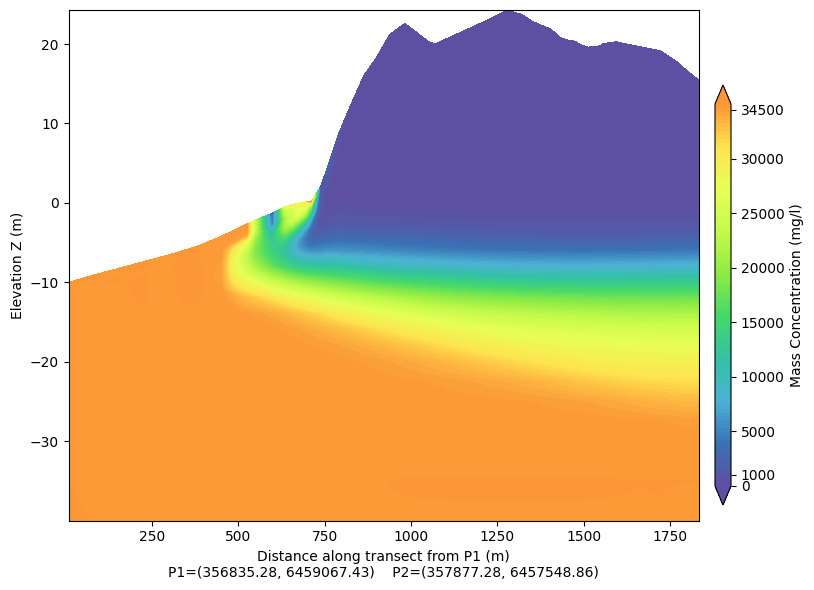

In [17]:
fig = plot_cross_section(targets_vals)
fig.savefig('/scratch/yl75/ak4177/src/GW_SciML/notebooks/figures/feflow_cross_section.png')

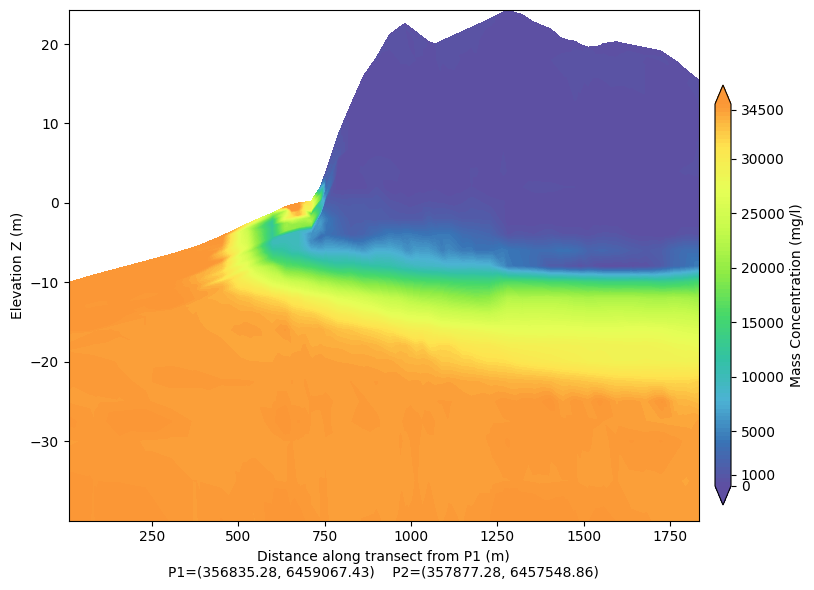

In [18]:
fig = plot_cross_section(gino_vl_preds_vals)
fig.savefig('/scratch/yl75/ak4177/src/GW_SciML/notebooks/figures/gino_vl_cross_section.png')

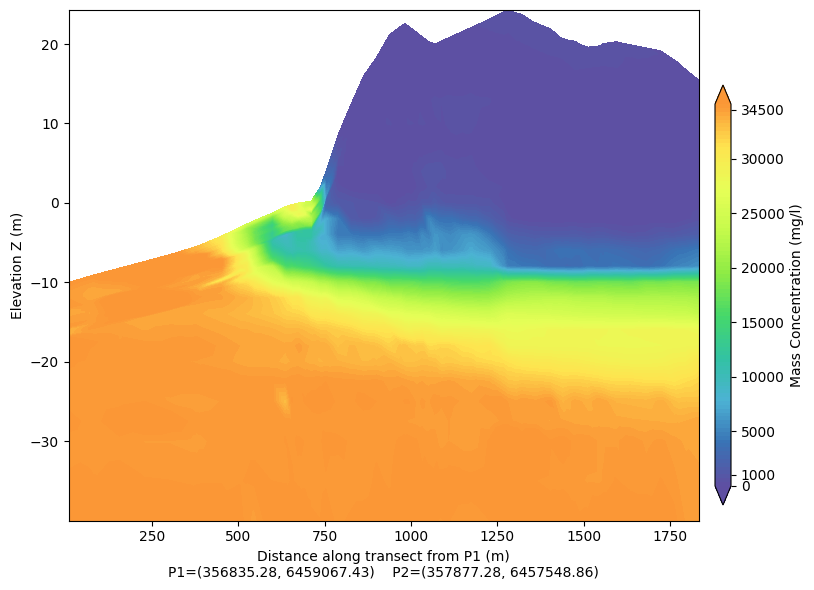

In [19]:
fig = plot_cross_section(gino_preds_vals)
fig.savefig('/scratch/yl75/ak4177/src/GW_SciML/notebooks/figures/gino_cross_section.png')

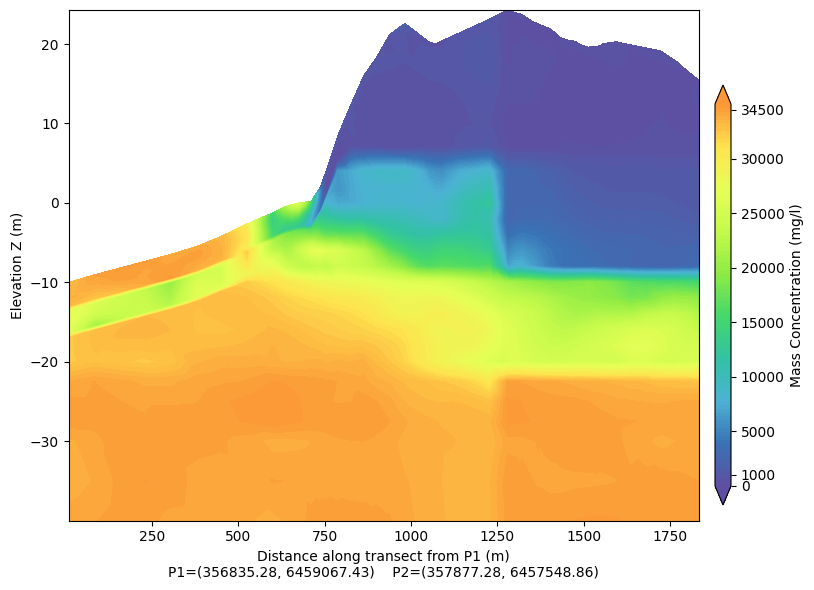

In [20]:
fig = plot_cross_section(fno_preds_vals)
fig.savefig('/scratch/yl75/ak4177/src/GW_SciML/notebooks/figures/fno_cross_section.png')